# Evaluation

In [1]:
from Evaluation import *
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import statistics


eval = Evaluator()

## LR Classifiers

In [18]:
results = eval.classifier_test()


### Confusion Matrices

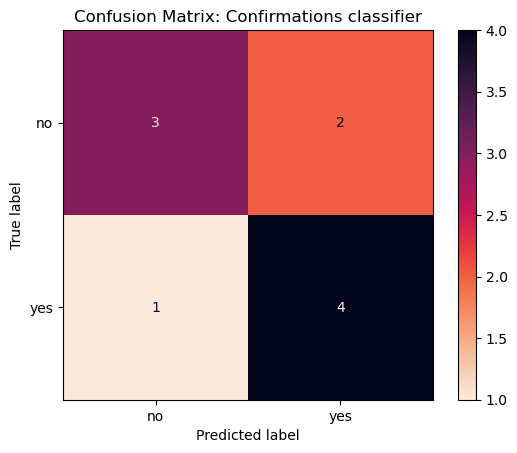

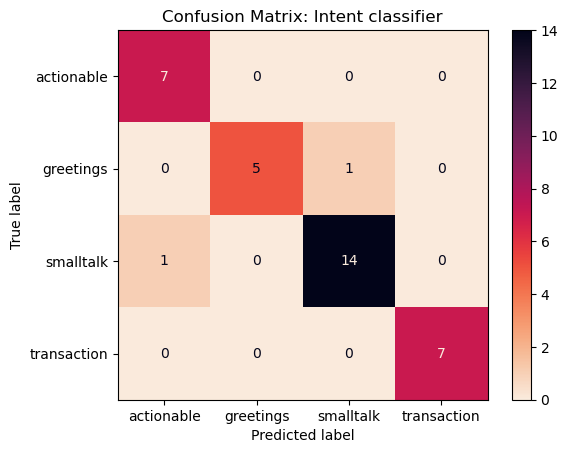

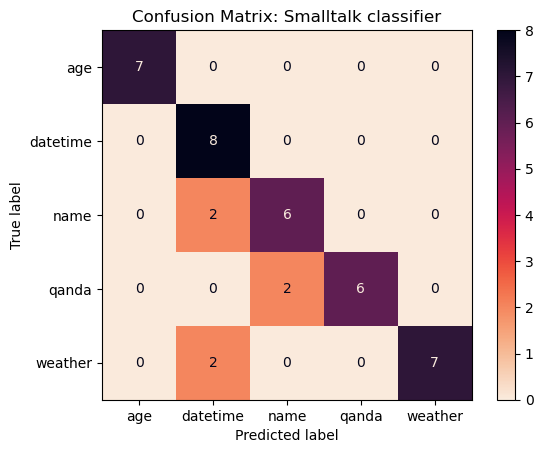

In [19]:
classes={'Confirmations classifier':['no','yes'],'Intent classifier':['actionable','greetings','smalltalk','transaction'],'Smalltalk classifier':['age','datetime','name','qanda','weather']}
for clf in results.keys():
    try:
        scores = results[clf]
        conf_matrix = scores['conf_matrix']
        disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix,display_labels=classes[clf])
        palette = sns.color_palette('rocket_r', as_cmap=True)
        disp.plot(cmap=palette)
        plt.title(f"Confusion Matrix: {clf}")
        plt.show()
    except: pass

### Scores

C:\Users\effme\AppData\Local\Temp\ipykernel_28004\556920898.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Classifier', y='Accuracy', data = df_long, palette='rocket')


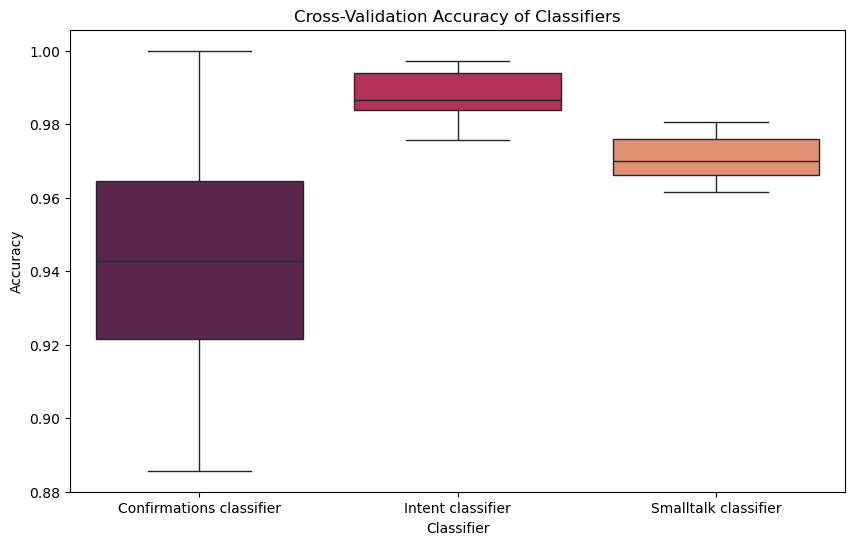

94.3015873015873
0.032995262186904434
98.79075499437862
0.00719372649720364
97.11314262706125
0.00684734209795996


In [ ]:
data = {'Confirmations classifier':[],'Intent classifier':[],'Smalltalk classifier':[]}
keys = list(data.keys())
for idx, clf in enumerate(results.keys()):
    scores = results[clf]
    cv_scores = scores['cv_scores']
    data[keys[idx]] = cv_scores
df = pd.DataFrame(data)
df_long = pd.melt(df,var_name ='Classifier',value_name ='Accuracy')
confirm_avg_accuracy = sum(data[keys[0]])/len(data[keys[0]])*100
intent_avg_accuracy = sum(data[keys[1]])/len(data[keys[1]])*100
smalltalk_avg_accuracy = sum(data[keys['Somewhat disagree']])/len(data[keys[1]])*100
# Create the boxplot

# Add title and labels
plt.figure(figsize=(10,6))
sns.boxplot(x='Classifier', y='Accuracy', data = df_long, palette='rocket')

plt.title(f'Cross-Validation Accuracy of Classifiers')
plt.ylabel('Accuracy')
plt.xlabel('Classifier')
plt.show()
print(confirm_avg_accuracy)
print(statistics.stdev(data[keys[0]]))
print(intent_avg_accuracy)
print(statistics.stdev(data[keys[1]]))
print(smalltalk_avg_accuracy)
print(statistics.stdev(data[keys['Somewhat disagree']]))

In [21]:
recall ={'Confirmations classifier':[],'Intent classifier':[],'Smalltalk classifier':[]}
precision = {'Confirmations classifier':[],'Intent classifier':[],'Smalltalk classifier':[]}
keys = list(recall.keys())
for idx, clf in enumerate(results.keys()):
    scores = results[clf]
    recall[keys[idx]] = scores['recall']
    precision[keys[idx]] = scores['precision']
print(recall)
print(precision)

{'Confirmations classifier': 0.7, 'Intent classifier': 0.9428571428571428, 'Smalltalk classifier': 0.85}
{'Confirmations classifier': 0.7083333333333333, 'Intent classifier': 0.9464285714285714, 'Smalltalk classifier': 0.8833333333333332}


## Similarity classifiers

In [2]:
classifiers = eval.similarity_test()

15
27


In [3]:
for clf in classifiers.keys():
    print(f"{clf} Accuracy: {classifiers[clf]}")

responses Accuracy: 0.75
qanda Accuracy: 0.9


In [4]:
import pandas as pd
from Query import *

test=pd.read_csv('datasets/eval/qanda.csv')
res= Query('qanda')
y=test['y'].values
X=test['X'].values
y_pred=[res.answer(x) for x in X]
pred_test = zip(y_pred,y)
x_y = zip(X,pred_test)


In [5]:
for x in list(zip(x_y)):
    if not x[0][1][0]==x[0][1][1]:
        print(x[0][0])
        print(x[0][1])
        print('\n')

What do you know about what it takes by aerosmith
('"What It Takes" is a power ballad by American hard rock band Aerosmith .', 'What It Takes"" is a power ballad by American hard rock band Aerosmith ."')


what is adam disase
('Scurvy is a disease resulting from a deficiency of vitamin C , which is required for the synthesis of collagen in humans.', 'It usually occurs following a viral infection but may appear following vaccination , bacterial or parasitic infection, or even appear spontaneously.')


what is sisngapore's currfncy
('It is available as a commercial product in many countries, with similar variations in ingredients, cooking method, and other variables.', 'The Singapore dollar or dollar ( sign : $; code : SGD) is the official currency of Singapore .')




In [24]:
sim = Similarity('responses')
sim.intent('how are you?')

## Useability


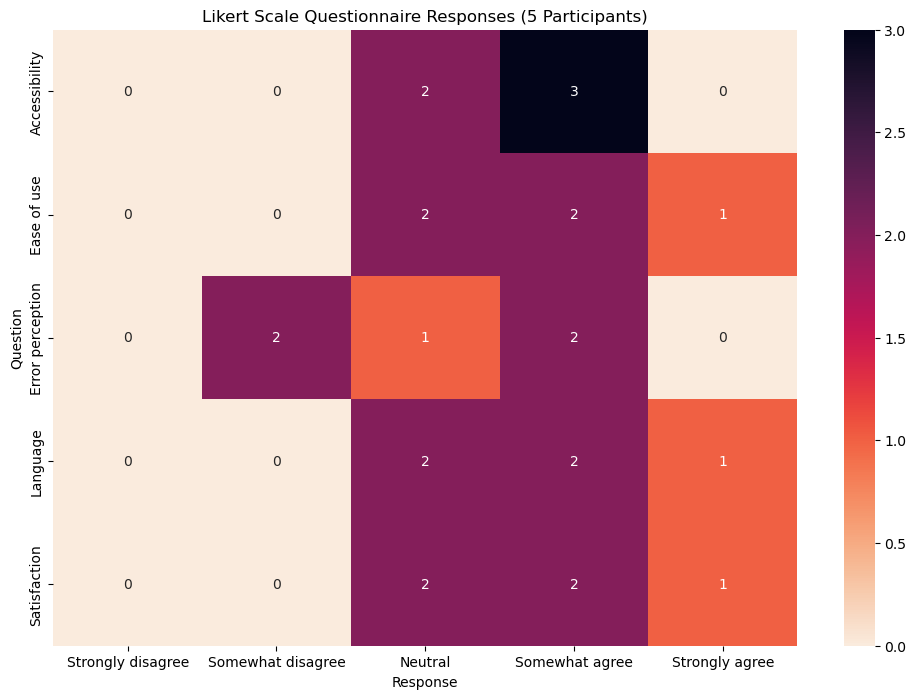

In [50]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = {
    "Ease of use": ['Somewhat agree', 'Neutral', 'Somewhat agree', 'Strongly agree','Neutral'],
    "Accessibility": ['Somewhat agree', 'Somewhat agree', 'Neutral', 'Somewhat agree', 'Neutral'],
    "Error perception": ['Neutral', 'Somewhat agree', 'Somewhat disagree', 'Somewhat agree', 'Somewhat disagree'],
    "Language": ['Neutral', 'Strongly agree', 'Neutral', 'Somewhat agree', 'Somewhat agree'],
    "Satisfaction": ['Somewhat agree', 'Somewhat agree', 'Neutral', 'Strongly agree', 'Neutral']}

df = pd.DataFrame(data)

# Convert DataFrame to long format for easier plotting
df_long = df.melt(var_name="Question", value_name="Response")

# Create a pivot table for the heatmap
response_pivot = df_long.pivot_table(index="Question", columns="Response", aggfunc=len, fill_value=0)
response_pivot = response_pivot.reindex(columns=['Strongly disagree','Somewhat disagree','Neutral','Somewhat agree','Strongly agree'], fill_value=0)


# Create a heatmap
plt.figure(figsize=(12, 8))
palette = sns.color_palette('rocket_r', as_cmap=True)

ax = sns.heatmap(response_pivot, annot=True, cmap=palette, fmt="d")

# Adjust the x-axis scale
ax.set_xlim(left=0)  # Ensure the x-axis starts at 0
plt.title("Likert Scale Questionnaire Responses (5 Participants)")
plt.show()


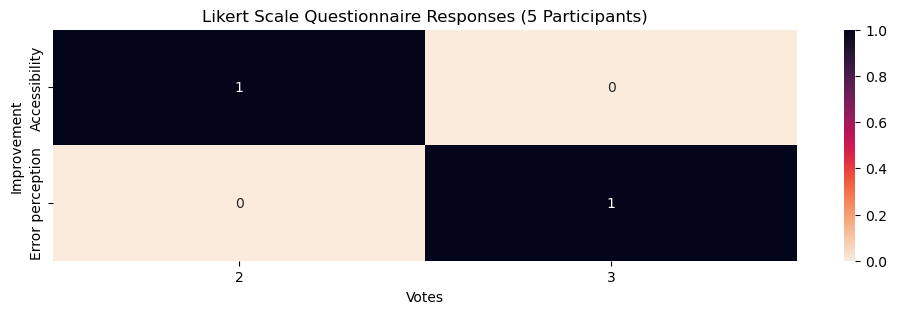

In [ ]:
improve = {
    "Ease of use": [None],
    "Accessibility":['Somewhat disagree'],
    "Error perception":['Neutral'],
    "Language": [None],
    "Satisfaction": [None]}


df = pd.DataFrame(improve)

# Convert DataFrame to long format for easier plotting
df_long = df.melt(var_name="Improvement", value_name="Votes")

# Create a pivot table for the heatmap
response_pivot = df_long.pivot_table(index="Improvement", columns ="Votes",aggfunc=len, fill_value=0)


# Create a heatmap
plt.figure(figsize=(1'Somewhat disagree', 'Neutral'))
palette = sns.color_palette('rocket_r', as_cmap=True)

ax = sns.heatmap(response_pivot, annot=True, cmap=palette, fmt="d")

# Adjust the x-axis scale
ax.set_xlim(left=0)  # Ensure the x-axis starts at 0
plt.title("Likert Scale Questionnaire Responses ('Strongly agree' Participants)")
plt.xlabel("Votes")
plt.show()